例 18.5 (续例 4.27) 试利用太阳黑子个数文件 `sunspots.csv` (数据见封底二维码), 建立适当的 ARMA 模型, 并预测 1989 年太阳黑子个数.  

解 可以使用 `statsmodels.tsa.api.ARIMA()` 函数来拟合 ARMA 模型, 下面先初步地使用 ARMA(9, 1) 模型来拟合数据, 得到 1989 年太阳黑子预测值为 $141$ 个.  

最终结果如图 18.1 所示.  

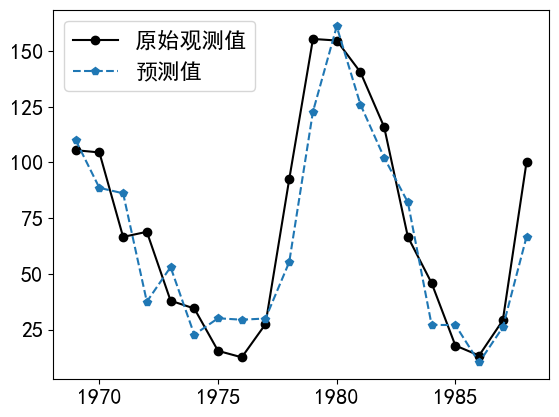

289    140.889482
dtype: float64
下一期预测值:
289    140.889482
dtype: float64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ARIMA  # Time Series Analysis
from pmdarima import auto_arima

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['font.size'] = 16

# 读取数据并提取为一维Series
df = pd.read_csv('sunspots.csv', usecols=['counts'])['counts']  # 改为提取Series, 形状为(289,)

# best_params = auto_arima(
#     df,  # Series
#     trace=False,
#     suppress_warnings=True,
#     stepwise=True,
#     seasonal=False,
#     max_p=15, max_q=15,
#     max_d=2,
#     error_action='ignore'
# )
# print(best_params)

model = ARIMA(df, order=(9, 0, 1)).fit()  # 明确指定order参数
years = np.arange(1700, 1989)  # 已知观测值的年代
df_hat = model.predict()

# 绘制最后20个观测值和预测值
plt.plot(years[-20:], df.values[-20:], 'o-k', label='原始观测值')
plt.plot(years[-20:], df_hat.values[-20:], 'p--', label='预测值')
plt.legend()
plt.show()

dnext = model.predict(df.shape[0], df.shape[0])
print(dnext)
# 预测下一期(使用forecast方法预测未来, predict拟合样本)
df_next = model.forecast(steps=1)  # 预测未来1步
print(f"下一期预测值:\n{df_next}")

对于例 18.5, 下面给出一个完整的建模步骤。  

第一步:画出原始数据的折线图如图 18.2 所示, 初步确定观测数据是平稳的。画出序列的自相关图和偏相关图如图 18.3 所示。  

第二步:利用 AIC(Akaike Information Criterion, 赤池信息准则  )和 BIC(Bayesian Information Criterion, 贝叶斯信息准则  )准则, 从众多可能的 ARMA 模型结构里, 确定选择 $ \text{ARMA}(4,2) $。借助 Python 软件(通常用 `statsmodels` 库的 `ARMA` 或 `ARIMA` 类  )拟合模型, 求得模型计算结果(如系数估计、统计检验等信息)如图 18.4 所示；同时分析残差(模型预测值与实际值的差值  ), 其取值及分布情况(可看残差的折线图、直方图、QQ 图等  )如图 18.5, 用于判断模型拟合质量, 若残差近似白噪声, 说明模型能较好捕捉数据规律。  

第三步:基于拟合好的 $ \text{ARMA}(4,2) $ 模型, 对 1989 年太阳黑子个数做预测, 得到预测值为 139 个 。将原始数据与预测值对比展示(如图 18.6 折线图等形式  ), 直观呈现模型预测效果, 辅助验证模型对太阳黑子序列的拟合及预测能力 。  

简单说, 就是用信息准则选模型、拟合后看残差评估、最后用模型预测并对比数据 , 完成 ARMA 建模流程来解决太阳黑子个数预测问题 。

这是在为建立 ARMA 模型做前期准备, 通过观察原始数据折线图判断平稳性, 借助自相关图和偏相关图辅助确定 ARMA 模型的阶数等参数 , 后续一般还会有模型拟合、检验、预测等步骤 , 不过目前仅呈现了第一步内容 , 若有完整需求, 还需结合后续步骤来全面构建 ARMA 建模流程 , 比如根据自相关和偏相关图定阶后, 用 `statsmodels` 里的 `ARMA` 函数拟合, 再进行模型诊断(如残差分析等), 最后实现预测 。 

[1, 1, 2534.4152973149608, 2549.0810040674105]
[1, 2, 2486.3625230804187, 2504.694656520981]
[1, 3, 2481.646979063503, 2503.6455391921772]
[1, 4, 2501.810774424605, 2527.475761241392]
[1, 5, 2478.4622605031327, 2507.793674008032]
[2, 1, 2451.5373784871254, 2469.8695119276877]
[2, 2, 2452.4263853726834, 2474.424945501358]
[2, 3, 2454.3953823279608, 2480.0603691447477]
[2, 4, 2436.757559730566, 2466.0889732354653]
[2, 5, 2435.389803117612, 2468.387643310624]
[3, 1, 2450.7986554381505, 2472.797215566825]
[3, 2, 2452.786573270836, 2478.451560087623]
[3, 3, 2411.6547739815614, 2440.986187486461]
[3, 4, 2411.7421002696956, 2444.7399404627076]
[3, 5, 2408.4030205695008, 2445.067287450625]
[4, 1, 2452.7880494531496, 2478.4530362699365]
[4, 2, 2451.5006214136774, 2480.832034918577]
[4, 3, 2451.6335375515127, 2484.631377744525]
[4, 4, 2410.702576077386, 2447.36684295851]
[4, 5, 2410.2979955790115, 2450.628689148248]
[5, 1, 2454.675268114766, 2484.0066816196654]
[5, 2, 2451.4100600987667, 2484.40

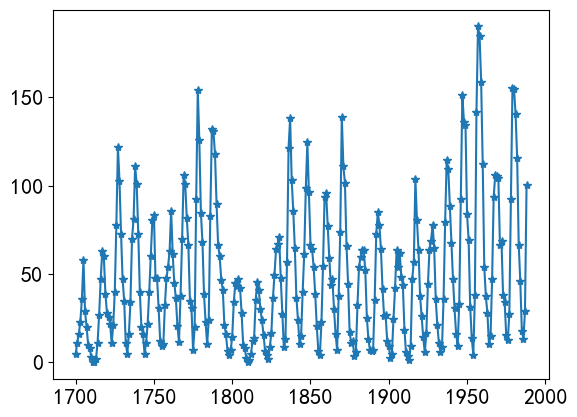

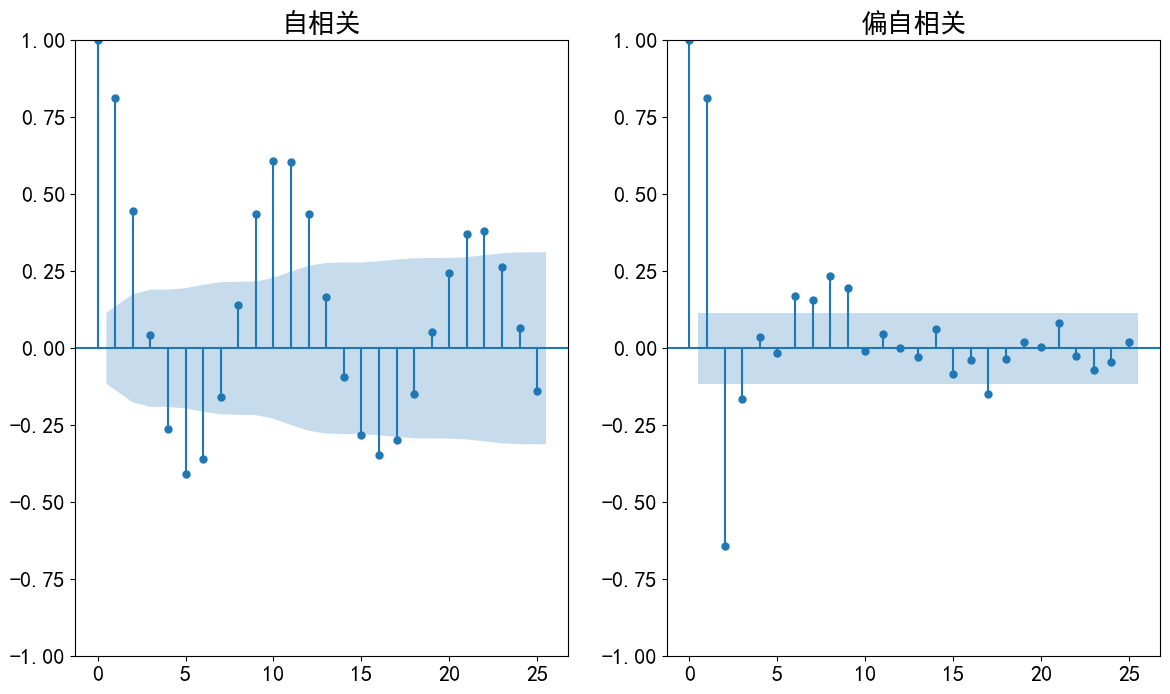

<Figure size 1400x800 with 0 Axes>

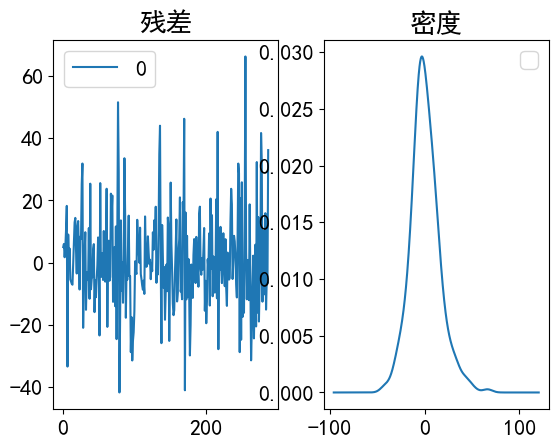

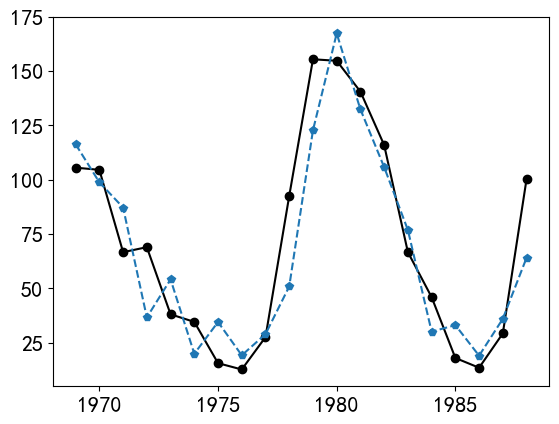

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
import pmdarima as pm

"""
plot_acf:绘制时间序列的自相关函数(Autocorrelation Function, ACF)图, 显示序列在不同滞后阶数(lag)下的自相关系数。
自相关系数衡量序列在时间 t 的值与时间 t-k (滞后 k )的值之间的相关性。
plot_pacf:绘制偏自相关函数(Partial Autocorrelation Function, PACF)图, 显示序列在不同滞后阶数下的偏自相关系数。
偏自相关系数是在控制较低阶滞后影响后, 当前滞后与序列的相关性。

意义:
ACF:帮助判断时间序列的平稳性和是否存在周期性模式。对于 ARIMA 模型, ACF 图可用于识别 MA(移动平均)部分的阶数(q)。如果 ACF 图在某阶后快速衰减到接近零, 说明序列可能是平稳的。
PACF:用于识别 AR(自回归)部分的阶数(p)。PACF 图在某阶后趋于零的点通常提示 AR 模型的合适阶数。

两者均值越小越好
md.aic:获取 ARIMA 模型的 赤池信息准则(Akaike Information Criterion, AIC), 用于评估模型的拟合质量。
md.bic:获取 ARIMA 模型的 贝叶斯信息准则(Bayesian Information Criterion, BIC), 同样用于模型选择。

(p,d,q): 非季节性 ARIMA 模型的参数，分别表示自回归阶数、差分阶数和移动平均阶数。
(P,D,Q)[m]: 季节性 ARIMA 参数（你的数据中均为 (0,0,0)[0]，表示无季节性成分）。
intercept: 是否包含截距项(常数项)。
AIC: 模型的 AIC 值。
Time: 拟合模型所需的时间。

zmd.resid:提取 ARIMA 模型的残差(residuals), 即实际值与模型预测值之间的差值
pd.DataFrame(zmd.resid):将残差(通常是一个 numpy 数组或 pandas Series)转换为 pandas DataFrame 格式, 便于后续绘图或分析

残差时间序列图(ax[0]):

显示残差值随时间的变化。
理想情况下, 残差应围绕 0 波动, 无明显趋势、周期或异方差(方差变化)。
如果残差图显示系统性模式(例如, 周期性波动或趋势), 说明模型可能未完全捕捉数据特征, 需调整 $ p, d, q $ 或考虑季节性 ARIMA(SARIMA)。


残差密度图(ax[1]):

KDE 图展示残差的概率密度分布, 类似直方图但更平滑。
理想情况下, 残差应接近正态分布(均值约 0, 形状接近钟形曲线), 因为 ARIMA 模型假设残差为正态白噪声。
如果密度图偏斜或有多个峰值, 可能提示模型拟合不足或数据存在非正态特性。
"""
warnings.filterwarnings("ignore")

plt.rcParams['font.sans-serif'] = ['SimHei']    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 16

d = pd.read_csv('sunspots.csv')
dd = d['counts']  # series, (289,)
years = d['year'].values.astype(int)

plt.plot(years, dd.values, '-*')

plt.figure(figsize=(14, 8))
ax1 = plt.subplot(121)
plot_acf(dd, ax=ax1, title='自相关')
ax2 = plt.subplot(122)
plot_pacf(dd, ax=ax2, title='偏自相关')

for i in range(1, 6):
    for j in range(1, 6):
        md = ARIMA(dd, order=(i, 0, j)).fit()
        print([i, j, md.aic, md.bic])

auto_model = pm.auto_arima(dd, seasonal=False, trace=True)
print(auto_model.summary())
      
zmd = ARIMA(dd, order=(2, 1, 3)).fit()
print(zmd.summary())  # 显示模型的所有信息

residuals = pd.DataFrame(zmd.resid)

fig, ax = plt.subplots(1, 2)
residuals.plot(title='残差', ax=ax[0])
residuals.plot(kind='kde', title='密度', ax=ax[1])
plt.legend('')
plt.ylabel('')

dhat = zmd.predict()
plt.figure()
plt.plot(years[-20:], dd.values[-20:], 'o-k', label='原始观测值')
plt.plot(years[-20:], dhat.values[-20:], 'p--', label='预测值')

dnext = md.forecast(step=1)
print(dnext)

plt.show()

In [32]:
residuals

,0
0,5.000000
1,5.998407
2,1.715758
3,5.042383
4,10.752633
...,...
284,15.893074
285,-15.122479
286,-5.546773
287,-6.723653
